# Logistic Regression with Horseshoe Prior

This notebook mirrors the sampler comparison in `multivariate_probit.ipynb`, but uses the sparse logistic regression posterior with a horseshoe prior from `experiments.targets.LogisticRegressionHorseshoe`.

For observations $i=1,\ldots,n$,
$$
Y_i \mid X_i, \beta \sim \mathrm{Bernoulli}(\sigma(X_i^\top\beta)), \qquad \sigma(t)=\frac{1}{1+e^{-t}}.
$$
The prior is the horseshoe hierarchy
$$
\beta_j \mid \lambda_j, \tau \sim N(0, \tau^2\lambda_j^2), \qquad \lambda_j \sim C^+(0,1), \qquad \tau \sim C^+(0,1).
$$
The target is parameterized by the unconstrained state `(beta, log_lambda_local, log_tau_global)`.

In [79]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd

from numpyro.infer import HMC, MCMC, NUTS

from src.cauchy_mh import independent_cauchy_mh
from src.scp_core import SCP
from experiments.targets import LogisticRegressionHorseshoe

### Generate Synthetic Data and Set Up Target

In [80]:
def make_beta_true(p, n_nonzero, signal, intercept=-0.25):
    beta_true = jnp.zeros(p)
    beta_true = beta_true.at[0].set(intercept)
    n_active = min(n_nonzero, max(p - 1, 0))
    values = jnp.linspace(signal, 0.5 * signal, n_active)
    signs = jnp.where(jnp.arange(n_active) % 2 == 0, 1.0, -1.0)
    return beta_true.at[1:1 + n_active].set(values * signs)


def build_logistic_dataset(n, p, n_nonzero, signal, seed):
    key = jax.random.key(seed)
    key_x, key_y = jax.random.split(key)
    X_covariates = jax.random.normal(key_x, shape=(n, p - 1))
    X_covariates -= jnp.mean(X_covariates, axis=0, keepdims=True)
    X_covariates /= jnp.std(X_covariates, axis=0, keepdims=True) + 1e-6
    X = jnp.hstack([jnp.ones((n, 1)), X_covariates])
    beta_true = make_beta_true(p, n_nonzero, signal)
    logits = X @ beta_true
    p_success = jax.nn.sigmoid(logits)
    y = jax.random.bernoulli(key_y, p_success).astype(jnp.float32)
    return X, y, beta_true, p_success

In [81]:
cfg = {
    "n": 120,
    "p": 10,
    "n_nonzero": 5,
    "signal": 1.,
    "seed": 0
}

X, y, beta_true, p_success = build_logistic_dataset(
    n=cfg["n"],
    p=cfg["p"],
    n_nonzero=cfg["n_nonzero"],
    signal=cfg["signal"],
    seed=cfg["seed"],
)

target = LogisticRegressionHorseshoe(X, y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("state dimension:", target.d)
print("event rate:", float(jnp.mean(y)))
print("initial log_prob:", float(target.log_prob(target.initial_state())))

pd.DataFrame({"beta_true": beta_true})

X shape: (120, 10)
y shape: (120,)
state dimension: 21
event rate: 0.5333333611488342
initial log_prob: -90.80231475830078


,beta_true
0,-0.250
1,1.000
2,-0.875
3,0.750
4,-0.625
5,0.500
6,0.000
7,0.000
8,0.000
9,0.000


In [82]:
state0 = target.initial_state()
beta0, log_lambda0, log_tau0 = target.unpack(state0)

print("initial state shape:", state0.shape)
print("beta shape:", beta0.shape)
print("log_lambda_local shape:", log_lambda0.shape)
print("log_tau_global shape:", jnp.shape(log_tau0))
print("initial log_prob finite:", bool(jnp.isfinite(target.log_prob(state0))))

initial state shape: (21,)
beta shape: (10,)
log_lambda_local shape: (10,)
log_tau_global shape: ()
initial log_prob finite: True


### NUTS

In [83]:
nuts_kernel = NUTS(potential_fn=lambda state: -target.log_prob(state))
nuts_mcmc = MCMC(
    nuts_kernel,
    num_warmup=100,
    num_samples=2000,
    thinning=1,
    num_chains=1,
)
nuts_mcmc.run(
    jax.random.key(cfg["seed"] + 10),
    init_params=target.initial_state(),
    extra_fields=("accept_prob",),
)

nuts_samples = nuts_mcmc.get_samples()
nuts_beta_samples = target.extract_beta(nuts_samples)
nuts_accept_rate = jnp.mean(nuts_mcmc.get_extra_fields()["accept_prob"])

print("NUTS acceptance rate:", float(nuts_accept_rate))
print("NUTS sample shape:", nuts_samples.shape)
print("NUTS beta sample shape:", nuts_beta_samples.shape)

sample: 100%|██████████| 2100/2100 [00:00<00:00, 2749.25it/s, 31 steps of size 1.44e-01. acc. prob=0.70]

NUTS acceptance rate: 0.7042579650878906
NUTS sample shape: (2000, 21)
NUTS beta sample shape: (2000, 10)


### HMC

In [84]:
hmc_kernel = HMC(
    potential_fn=lambda state: -target.log_prob(state),
    step_size=0.1,
    adapt_step_size=True,
    adapt_mass_matrix=False,
    num_steps=10,
    trajectory_length=None,
)
hmc_mcmc = MCMC(
    hmc_kernel,
    num_warmup=200,
    num_samples=2000,
    thinning=1,
    num_chains=1,
)
hmc_mcmc.run(
    jax.random.key(cfg["seed"] + 10),
    init_params=target.initial_state(),
    extra_fields=("accept_prob",),
)

hmc_samples = hmc_mcmc.get_samples()
hmc_beta_samples = target.extract_beta(hmc_samples)
hmc_accept_rate = jnp.mean(hmc_mcmc.get_extra_fields()["accept_prob"])

print("HMC acceptance rate:", float(hmc_accept_rate))
print("HMC sample shape:", hmc_samples.shape)
print("HMC beta sample shape:", hmc_beta_samples.shape)

sample: 100%|██████████| 2200/2200 [00:00<00:00, 3773.32it/s, 10 steps of size 2.49e-02. acc. prob=0.93]

HMC acceptance rate: 0.9294340014457703
HMC sample shape: (2000, 21)
HMC beta sample shape: (2000, 10)


### Independent Cauchy MH

In [85]:
cauchy_samples, cauchy_accept_rate = independent_cauchy_mh(
    target.log_prob,
    target.initial_state(),
    jax.random.key(cfg["seed"] + 10),
    nsample=2000,
    burnin=100,
    thinning=1,
    stepsize=0.01,
)

cauchy_beta_samples = target.extract_beta(cauchy_samples)

print("Independent Cauchy MH acceptance rate:", float(cauchy_accept_rate))
print("Independent Cauchy MH sample shape:", cauchy_samples.shape)
print("Independent Cauchy MH beta sample shape:", cauchy_beta_samples.shape)

Running for 2,100 iterations: 100%|██████████| 2100/2100 [00:00<00:00, 52573.38it/s]

Independent Cauchy MH acceptance rate: 0.003000000026077032
Independent Cauchy MH sample shape: (2000, 21)
Independent Cauchy MH beta sample shape: (2000, 10)


### SCP

In [87]:
scp_model = SCP(
    d=target.d,
    latitude=1.8,
    affine='covariance',
)

opt_params, losses = scp_model.minimize_reverse_kl(
    target.log_prob,
    seed=cfg["seed"] + 10,
    ntrain=512,
    max_iter=1000,
    learning_rate=1e-2,
    clip_value=10,
    grad_clip_norm=10,
)

print("final SCP training loss:", float(losses[-1]))

Running for 1,000 iterations: 100%|██████████| 1000/1000 [00:00<00:00, 2146.36it/s]

final SCP training loss: 60.70486831665039


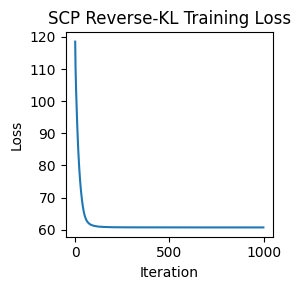

In [88]:
plt.figure(figsize=(3, 3))
plt.plot(losses)
plt.title("SCP Reverse-KL Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

In [89]:
u0 = scp_model.inverse_projection(opt_params, target.initial_state())
reprojected_state = scp_model.projection(opt_params, u0)

print("sphere state shape:", u0.shape)
print("reprojected log_prob:", float(target.log_prob(reprojected_state)))

sphere state shape: (22,)
reprojected log_prob: -90.80229949951172


In [103]:
scp_samples, scp_accept_rate = scp_model.rwm_bright_side(
    target.log_prob,
    opt_params,
    seed=cfg["seed"] + 10,
    x0=u0,
    stepsize=0.1,
    nsample=10000,
    burnin=100,
    thinning=5
)

scp_beta_samples = target.extract_beta(scp_samples)

print("SCP acceptance rate:", float(scp_accept_rate))
print("SCP sample shape:", scp_samples.shape)
print("SCP beta sample shape:", scp_beta_samples.shape)

Running for 10,100 iterations: 100%|██████████| 10100/10100 [00:00<00:00, 75265.83it/s]

SCP acceptance rate: 0.4125000238418579
SCP sample shape: (2000, 21)
SCP beta sample shape: (2000, 10)


### Beta Marginal Comparison

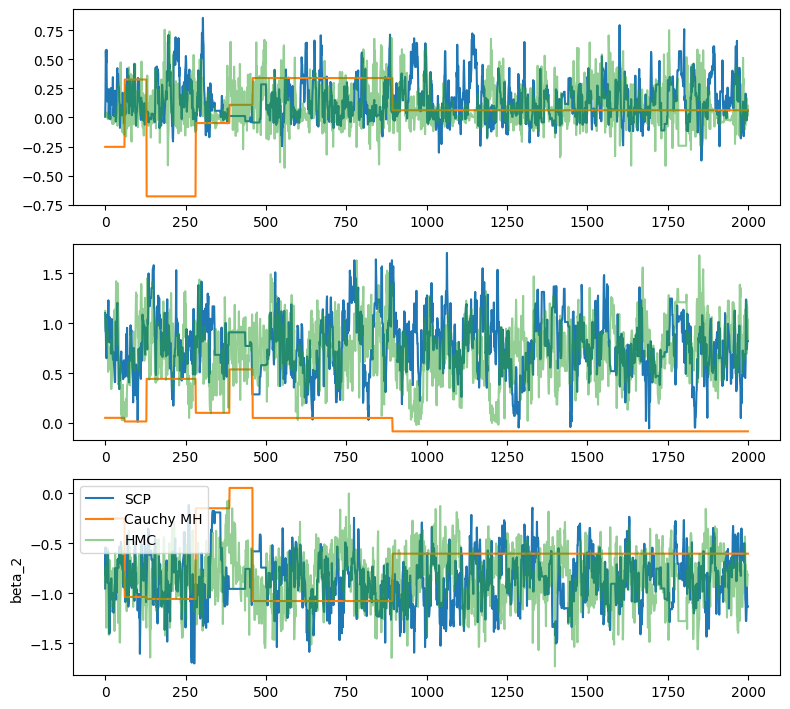

In [104]:
nplot = min(3, target.p)
fig, axes = plt.subplots(nplot, 1, figsize=(8, 2.4 * nplot), sharex=False)
if nplot == 1:
    axes = [axes]

for j, ax in enumerate(axes):
    ax.plot(scp_beta_samples[:, j], label="SCP")
    ax.plot(cauchy_beta_samples[:, j], label="Cauchy MH")
    ax.plot(hmc_beta_samples[:, j], label="HMC", alpha=.5)
    

axes[-1].set_ylabel(f"beta_{j}")
axes[-1].legend(loc="upper left")

plt.tight_layout()
plt.show()

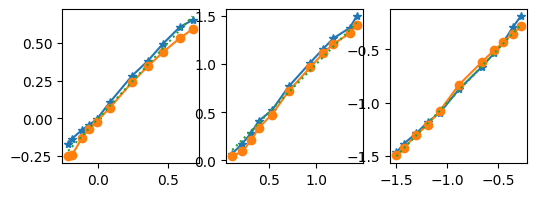

In [105]:
ps = jnp.array([0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 0.8, 0.9, 0.95, 0.98, 0.99])

def plot_quantiles(samples, ax):
    qs = jnp.quantile(samples, ps)
    ax.plot(ps, qs)

fig, ax = plt.subplots(1, 3, figsize=(6, 2))
for j in range(3):
    nuts_quantiles = jnp.quantile(nuts_beta_samples[:, j], ps)
    scp_quantiles = jnp.quantile(scp_beta_samples[:, j], ps)
    hmc_quantiles = jnp.quantile(hmc_beta_samples[:, j], ps)
    ax[j].plot(nuts_quantiles, scp_quantiles, "*-")
    ax[j].plot(nuts_quantiles, hmc_quantiles, "o-")
    ax[j].plot(nuts_quantiles, nuts_quantiles, ":")
